Clases encontradas: ['trash', 'trash_generadas', 'plastic', 'glass', 'metal', 'cardboard', 'paper']
Distribución de imágenes por clase:
class
paper        594
glass        501
plastic      482
metal        410
cardboard    404
trash        137
Name: count, dtype: int64


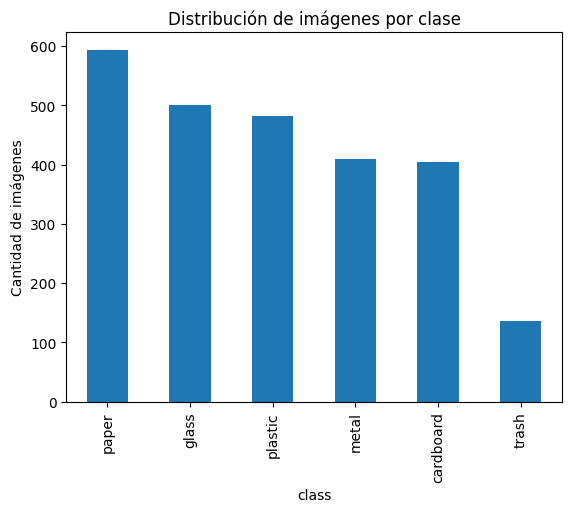

In [21]:
# EDA y Preparación del Dataset de Imágenes: garbage_classification

import os
import pandas as pd
import numpy as np
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

# Definir ruta base del dataset
base_path = '../data/raw/garbage_classification/'

# Listar carpetas de clases
clases = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
print('Clases encontradas:', clases)

# Contar imágenes por clase
df_imgs = []
for clase in clases:
    ruta = os.path.join(base_path, clase)
    imagenes = glob(os.path.join(ruta, '*.jpg'))
    df_imgs.extend([(img, clase) for img in imagenes])
df_imgs = pd.DataFrame(df_imgs, columns=['filepath', 'class'])

# Mostrar conteo por clase
distribucion = df_imgs['class'].value_counts().sort_values(ascending=False)
print('Distribución de imágenes por clase:')
print(distribucion)

# Visualizar la distribución
distribucion.plot(kind='bar', title='Distribución de imágenes por clase')
plt.ylabel('Cantidad de imágenes')
plt.show()

In [22]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

# --- 1. Definir Rutas y Cantidades ---
# Asume que 'pathta por kagglehub.dataset_download()

CLASE_OBJETIVO = 'trash'
NUM_IMAGENES_ACTUAL = 137
NUM_IMAGENES_MAXIMO = 420
NUM_A_GENERAR = NUM_IMAGENES_MAXIMO - NUM_IMAGENES_ACTUAL

# Directorio de la clase actual y un directorio temporal para generar
# Usar Path para manipulación de rutas y mkdir

directorio_clase = Path(base_path) / CLASE_OBJETIVO
directorio_temporal_gen = Path(base_path) / f'{CLASE_OBJETIVO}_generadas'

# Crear el directorio temporal si no existe
directorio_temporal_gen.mkdir(exist_ok=True)

print(f"Objetivo: Generar {NUM_A_GENERAR} imágenes para la clase '{CLASE_OBJETIVO}'.")

Objetivo: Generar 283 imágenes para la clase 'trash'.


In [23]:
# --- 2. Configuración de Data Augmentation ---
from pathlib import Path

# El 'ImageDataGenerator' no solo genera datos en la red neuronal, 
# sino que también tiene la opción de guardarlos en disco ('save_to_dir').
datagen = ImageDataGenerator(
    rotation_range=25,       # Rotación de +/- 25 grados
    width_shift_range=0.15,  # Desplazamiento horizontal (15%)
    height_shift_range=0.15, # Desplazamiento vertical (15%)
    shear_range=0.15,        # Distorsión de corte (shear)
    zoom_range=0.15,         # Zoom aleatorio (15%)
    horizontal_flip=True,    # Volteo horizontal (útil para la mayoría de objetos)
    brightness_range=[0.7, 1.3], # Cambio de brillo
    fill_mode='nearest',     # Rellena los huecos generados con los píxeles más cercanos
    # rescale=1./255         # NO USAR: para guardar, es mejor no normalizar
)

# --- 3. Generar y Guardar las Imágenes ---
# El método .flow_from_directory() te permite crear un flujo de generación a partir de las imágenes.
# Se debe apuntar a la carpeta que contiene la subcarpeta de la clase objetivo

directorio_padre = Path(base_path)  # base_path ya es la carpeta que contiene las clases

generador_flujo = datagen.flow_from_directory(
    directory=str(directorio_padre),
    classes=[CLASE_OBJETIVO],        # Solo se procesa la carpeta 'trash'
    target_size=(384, 512),          # Mantiene el tamaño promedio para la generación
    batch_size=1,                    # Procesa 1 imagen a la vez para aplicar transformaciones
    save_to_dir=str(directorio_temporal_gen),
    save_prefix='aug',               # Prefijo para los archivos generados
    save_format='jpeg'
)

# Bucle para generar el número exacto de imágenes
imagenes_generadas = 0
while imagenes_generadas < NUM_A_GENERAR:
    # `next(generador_flujo)` genera y guarda una imagen en disco
    next(generador_flujo)
    imagenes_generadas += 1

print(f"Proceso de generación completado. Se crearon {imagenes_generadas} imágenes.")

Found 137 images belonging to 1 classes.
Proceso de generación completado. Se crearon 283 imágenes.


In [24]:
# --- 4. Mover Imágenes a la Carpeta Final ---
import shutil

# Mueve todas las imágenes generadas a la carpeta original 'trash'
for archivo in directorio_temporal_gen.iterdir():
    if archivo.is_file() and archivo.suffix.lower() in ['.jpg', '.jpeg', '.png']:
        shutil.move(str(archivo), str(directorio_clase / archivo.name))

# --- 5. Verificar y Limpiar ---
# Eliminar el directorio temporal si está vacío
try:
    directorio_temporal_gen.rmdir()
except OSError:
    # Si quedan archivos, elimínalos manualmente o usa shutil.rmtree(..., ignore_errors=True)
    pass

num_final_trash = len(list(directorio_clase.glob('*.jpg'))) + len(list(directorio_clase.glob('*.jpeg'))) + len(list(directorio_clase.glob('*.png')))
print(f"El conteo final de imágenes en '{CLASE_OBJETIVO}' es: {num_final_trash}")

El conteo final de imágenes en 'trash' es: 420


In [26]:
import os
from pathlib import Path

# Asume que 'path_base' es la ruta a la carpeta contenedora del dataset
path_base = Path('../data/raw/garbage_classification/') 

# Definiciones de conteo originales
NUM_IMAGENES_MAXIMO = 594 # El objetivo, llegar a una cantidad parecida a'paper'

# Directorio de la clase 'trash'
directorio_clase_trash = path_base / 'trash'
# Directorio de la clase 'paper' (para comparación)
directorio_clase_paper = path_base / 'paper'

# 1. Contar imágenes en la clase TRASH (incluyendo las aumentadas)
conteo_trash_final = len([f for f in os.listdir(directorio_clase_trash) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# 2. Contar imágenes en la clase PAPER (referencia)
conteo_paper = len([f for f in os.listdir(directorio_clase_paper) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])


print("--- Resumen de Balanceo Post-Generación ---")
print(f"Clase 'trash' (FINAL): {conteo_trash_final} imágenes")
print(f"Clase 'paper' (Referencia): {conteo_paper} imágenes")

if conteo_trash_final >= NUM_IMAGENES_MAXIMO:
    print("✅ Balanceo exitoso: El conteo de 'trash' ha alcanzado o superado el objetivo.")
else:
    print("⚠️ Advertencia: El conteo de 'trash' es aún inferior al objetivo.")

--- Resumen de Balanceo Post-Generación ---
Clase 'trash' (FINAL): 420 imágenes
Clase 'paper' (Referencia): 594 imágenes
⚠️ Advertencia: El conteo de 'trash' es aún inferior al objetivo.


In [3]:
# --- 6. Split train/val/test sin duplicar imágenes (usa symlinks por defecto) ---
import random
from pathlib import Path
import shutil
import os

# Parámetros: ajustar según necesidad
path_base = Path('../data/raw/garbage_classification')
out_base = Path('../data/processed/garbage_classification_split')
splits = {'train': 0.7, 'val': 0.15, 'test': 0.15}  # deben sumar 1.0
seed = 42
mode = 'symlink'  # 'symlink' (por defecto) o 'copy' para copiar archivos en lugar de enlazarlos

# Crear carpetas de salida por clase
random.seed(seed)
out_base.mkdir(parents=True, exist_ok=True)
clases = [d for d in path_base.iterdir() if d.is_dir()]
print('Clases encontradas para split:', [c.name for c in clases])

for clase_dir in clases:
    archivos = [p for p in clase_dir.iterdir() if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]
    archivos.sort()  # orden determinista antes del shuffle
    random.shuffle(archivos)

    n = len(archivos)
    n_train = int(splits['train'] * n)
    n_val = int(splits['val'] * n)
    # assign
    train_files = archivos[:n_train]
    val_files = archivos[n_train:n_train + n_val]
    test_files = archivos[n_train + n_val:]

    for split_name, files in [('train', train_files), ('val', val_files), ('test', test_files)]:
        target_dir = out_base / split_name / clase_dir.name
        target_dir.mkdir(parents=True, exist_ok=True)
        for src in files:
            dst = target_dir / src.name
            if dst.exists():
                continue
            try:
                if mode == 'symlink':
                    # En sistemas Unix creamos un symlink relativo
                    rel_path = os.path.relpath(src, start=target_dir)
                    os.symlink(rel_path, dst)
                else:
                    shutil.copy2(src, dst)
            except Exception as e:
                print(f'Error al crear enlace/copia para {src} -> {dst}:', e)

# Mostrar conteos por split y clase
print('Conteos por split y clase:')
for split_name in ['train', 'val', 'test']:
    print(f'--- {split_name.upper()} ---')
    for clase_dir in clases:
        folder = out_base / split_name / clase_dir.name
        if folder.exists():
            cnt = len([p for p in folder.iterdir() if p.is_file()])
        else:
            cnt = 0
        print(f'{clase_dir.name}: {cnt}')

print('Split completado. Ruta de salida:', out_base)
print('Si necesita copiar archivos en lugar de symlinks cambie mode = "copy"')

Clases encontradas para split: ['trash', 'plastic', 'glass', 'metal', 'cardboard', 'paper']
Conteos por split y clase:
--- TRAIN ---
trash: 294
plastic: 337
glass: 350
metal: 287
cardboard: 282
paper: 415
--- VAL ---
trash: 63
plastic: 72
glass: 75
metal: 61
cardboard: 60
paper: 89
--- TEST ---
trash: 63
plastic: 73
glass: 76
metal: 62
cardboard: 62
paper: 90
Split completado. Ruta de salida: ../data/processed/garbage_classification_split
Si necesita copiar archivos en lugar de symlinks cambie mode = "copy"


## Notas sobre el split (train/val/test)

- Ruta de origen: `data/raw/garbage_classification/` — contiene subcarpetas por clase (ej. `trash`, `paper`, ...).
- Ruta de salida: `data/processed/garbage_classification_split/{train,val,test}/{class}/`. Por defecto se crean enlaces simbólicos (symlinks) para no duplicar los archivos en disco.
- Parámetros configurables en la celda de código:
  - `splits`: dict con proporciones para `train`, `val`, `test` (deben sumar ~1.0).
  - `seed`: semilla para reproducibilidad del shuffle.
  - `mode`: `'symlink'` (por defecto) o `'copy'` si prefieres duplicar físicamente los archivos (útil en sistemas sin soporte de symlinks o si necesitas mover los datos).
- Permisos: en Linux los symlinks suelen funcionar sin permiso extra. En Windows puede ser necesario ejecutar como administrador o usar `mode='copy'`.
- Para regenerar el split: elimina `data/processed/garbage_classification_split/` y vuelve a ejecutar la celda de split.
- Validación: la celda imprime un resumen de conteos por split y por clase al finalizar; usa esto para comprobar que no haya desbalances inesperados.

Si quieres, puedo refactorizar la celda en una función reutilizable (por ejemplo `make_split(path_base, out_base, splits, seed, mode)`) y añadir una pequeña prueba unitaria.